In [1]:
from pathlib import Path

import pandas as pd
from plots import plot_e

In [2]:
cmap = {
    "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
    "other": (1.0, 1.0, 0.7019607843137254),
    "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
    "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
    "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
    "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
    "education": (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
    "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
    "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
}


def latest(path: Path):
    versions = sorted(
        [
            d
            for d in path.iterdir()
            if d.is_dir() and d.name.startswith("version")
        ]
    )
    print(
        f"Found versions for {path.name}: {[v.name for v in versions]}. Returning {versions[-1]}"
    )
    return path.name, versions[-1]


def earliest(path: Path):
    versions = sorted(
        [
            d
            for d in path.iterdir()
            if d.is_dir() and d.name.startswith("version")
        ]
    )
    print(
        f"Found versions for {path.name}: {[v.name for v in versions]}. Returning {versions[-1]}"
    )
    return path.name, versions[0]


def iter_models(path: Path):
    for dir in path.iterdir():

        if dir.is_dir():

            yield latest(dir)


def find_nth(path: Path, n=0):

    ranks = (
        pd.read_csv(path / "domain_distances.csv")
        .drop(columns=["domain", "observed", "mean", "std"], errors="ignore")
        .rank(axis=1, method="min")
        .sum(axis=0)
    )
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def best_quality(path: Path, n=0):

    data = pd.read_csv(path / "domain_distances.csv")
    data = data[data.domain == "sample quality"].drop(
        columns=["domain", "observed", "mean", "std"], errors="ignore"
    )
    ranks = data.rank(axis=1, method="min").sum(axis=0)
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def load_attributes(path: Path, default=None):
    if (path / "synthetic_attributes.csv").exists():
        print(f"Loading synthetic attributes from {path}")
        return pd.read_csv(path / "synthetic_attributes.csv")
    if (path / "synthetic_labels.csv").exists():
        print(f"Loading synthetic labels from {path}")
        return pd.read_csv(path / "synthetic_labels.csv")
    print(f"Failed to find attributes at {path}")
    return default


def split_on(schedules, attributes, by="work_status"):
    splits = attributes.groupby(by)
    return {
        k: schedules.loc[schedules.pid.isin(list(v.pid))]
        for k, v in splits
        if k != "unknown"
    }

In [3]:
training_data_route = Path("../../tmp/foundation/experiment_e")

target_schedules = pd.read_csv(training_data_route / "target_activities.csv")
target_attributes = pd.read_csv(training_data_route / "target_attributes.csv")

training_attributes = {
    "aus": pd.read_csv(training_data_route / "qhts_attributes.csv"),
    "western": pd.read_csv(training_data_route / "western_attributes.csv"),
    # "world": pd.read_csv(training_data_route / "western2_attributes.csv"),
}

training_schedules = {
    "aus": pd.read_csv(training_data_route / "qhts_activities.csv"),
    "western": pd.read_csv(training_data_route / "western_activities.csv"),
    # "world": pd.read_csv(training_data_route / "western2_activities.csv"),
}

In [4]:
counter = {}
# load each and get counts per source
counter["baseline"] = target_attributes.source.value_counts()
for name, data in training_attributes.items():
    print(data.source.unique())
    counter[name] = data.source.value_counts()
df = pd.DataFrame(counter)


order = ["ltds", "vista", "qhts", "nhts", "nts"]
df = df.loc[order].fillna(0)
totals = df.sum()
totals_row = pd.DataFrame([totals], index=["Total"])
df = pd.concat([df, totals_row])
print(df.to_latex(float_format="{:.0f}".format))

['qhts']
['ltds' 'qhts' 'cmap' 'nhts' 'nts']
\begin{tabular}{lrrr}
\toprule
 & baseline & aus & western \\
\midrule
ltds & 0 & 0 & 17645 \\
vista & 25531 & 0 & 0 \\
qhts & 0 & 37002 & 37002 \\
nhts & 0 & 0 & 63888 \\
nts & 0 & 0 & 401781 \\
Total & 25531 & 37002 & 520316 \\
\bottomrule
\end{tabular}



In [5]:
def distance_table(batch_path, suffix=""):
    df = pd.read_csv(batch_path / f"domain_distances{suffix}.csv").set_index(
        "domain"
    )
    order = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]
    print(df.loc[order].to_latex(float_format="{:.3f}".format))
    return df.loc[order]


df = distance_table(Path("../../logs/foundations/E"), suffix="")

df

\begin{tabular}{lrrrrr}
\toprule
 & observed & baseline & aus & western & western2 \\
domain &  &  &  &  &  \\
\midrule
participations & 1.740 & 0.153 & 0.279 & 0.239 & 0.253 \\
transitions & 0.022 & 0.009 & 0.014 & 0.013 & 0.013 \\
timing & 0.418 & 0.036 & 0.188 & 0.047 & 0.046 \\
feasibility & 0.019 & 0.079 & 0.047 & 0.046 & 0.040 \\
creativity & 0.132 & 0.003 & 0.008 & 0.006 & 0.007 \\
\bottomrule
\end{tabular}



,observed,baseline,aus,western,western2
domain,,,,,
participations,1.740303,0.153359,0.278831,0.238907,0.253251
transitions,0.021644,0.009123,0.014441,0.012799,0.012667
timing,0.418139,0.036214,0.187708,0.047163,0.046149
feasibility,0.018722,0.079024,0.046936,0.046412,0.039779
creativity,0.131683,0.003453,0.007939,0.005971,0.006878


In [6]:
# df_alt = distance_table(Path("../../logs/foundations/B_alt"), suffix="")
# diff = 100 * (df - df_alt) / df_alt
# order = ["participations", "transitions", "timing", "feasibility", "creativity"]
# print(diff.loc[order].to_latex(float_format="{:.1f}\%".format))
# diff

In [7]:
# _ = plot_b(
#     training_schedules, training_attributes, target_schedules, target_attributes
# )

In [10]:
batch_root = Path("../../logs/foundations/E")

batch_paths = {
    "D0 (baseline)": batch_root / "baseline",
    "D1 (australian)": batch_root / "aus",
    "D2 (western)": batch_root / "western",
}

# find data
data_root = Path("../../tmp/foundation")
target_schedules = pd.read_csv(
    data_root / "experiment_e" / "target_activities.csv"
)
acts = list(target_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}

target_attributes = pd.read_csv(
    data_root / "experiment_e" / "target_attributes.csv"
)

schedules = {
    n: pd.read_csv(latest(p)[1] / "synthetic_schedules.csv")
    for n, p in batch_paths.items()
}
attributes = {
    n: load_attributes(latest(p)[1], default=target_attributes)
    for n, p in batch_paths.items()
}
print(schedules.keys())
print(attributes.keys())

Found versions for baseline: ['version_0', 'version_1', 'version_2', 'version_3', 'version_4', 'version_5']. Returning ../../logs/foundations/E/baseline/version_5
Found versions for aus: ['version_0', 'version_1', 'version_2', 'version_3']. Returning ../../logs/foundations/E/aus/version_3
Found versions for western: ['version_0']. Returning ../../logs/foundations/E/western/version_0
Found versions for baseline: ['version_0', 'version_1', 'version_2', 'version_3', 'version_4', 'version_5']. Returning ../../logs/foundations/E/baseline/version_5
Loading synthetic attributes from ../../logs/foundations/E/baseline/version_5
Found versions for aus: ['version_0', 'version_1', 'version_2', 'version_3']. Returning ../../logs/foundations/E/aus/version_3
Loading synthetic attributes from ../../logs/foundations/E/aus/version_3
Found versions for western: ['version_0']. Returning ../../logs/foundations/E/western/version_0
Loading synthetic attributes from ../../logs/foundations/E/western/version_0


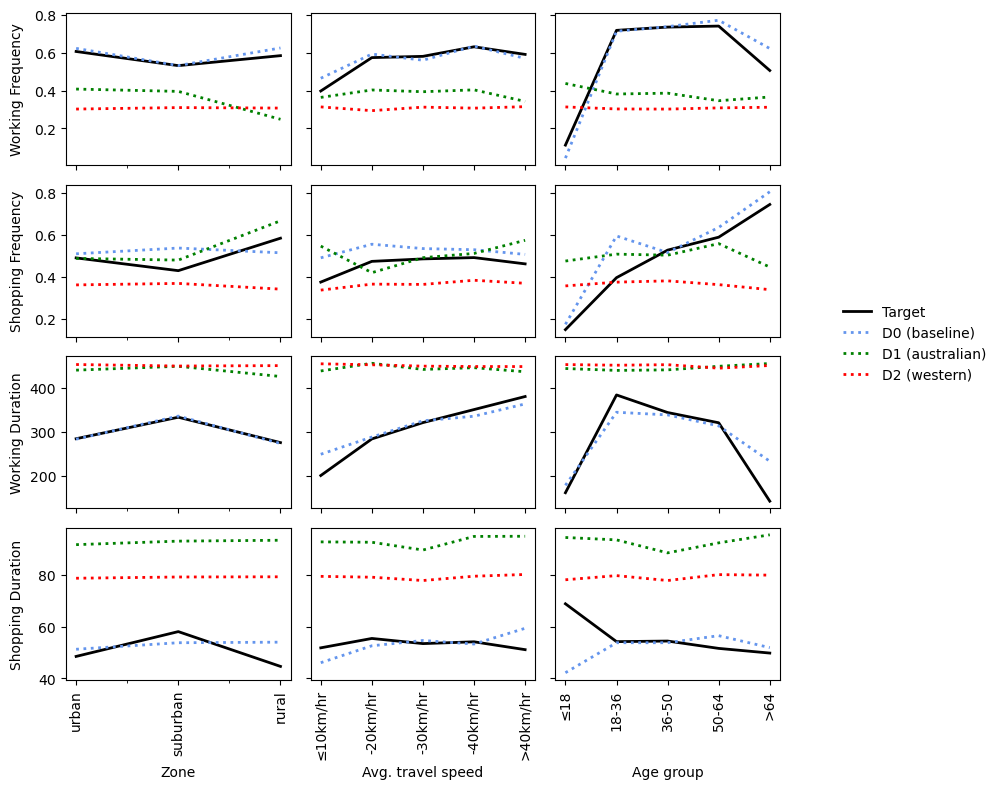

In [11]:
_ = plot_e(schedules, attributes, target_schedules, target_attributes)